# ЛР №5. "Обучение без учителя. Задача кластеризации"

## Генерация и загрузка датасетов

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_blobs, make_classification

In [ ]:
X_blobs, y_blobs = make_blobs(n_samples=500, centers=4, n_features=2, cluster_std=0.60, random_state=777)

X_class, y_class = make_classification(n_samples=500, n_features=2, n_redundant=0, n_informative=2, n_clusters_per_class=1, n_classes=3, class_sep=2.0, random_state=777)

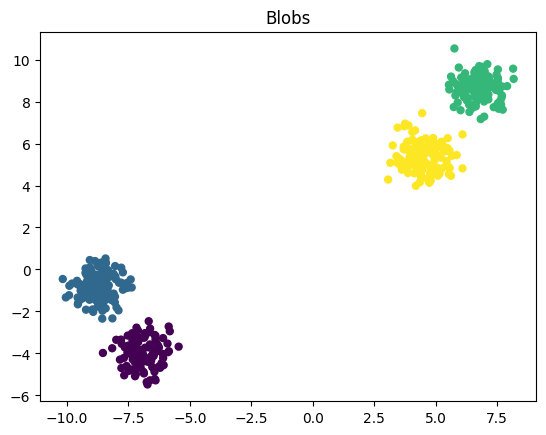

In [ ]:
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_blobs, s=25)
plt.title("Blobs")
plt.show()

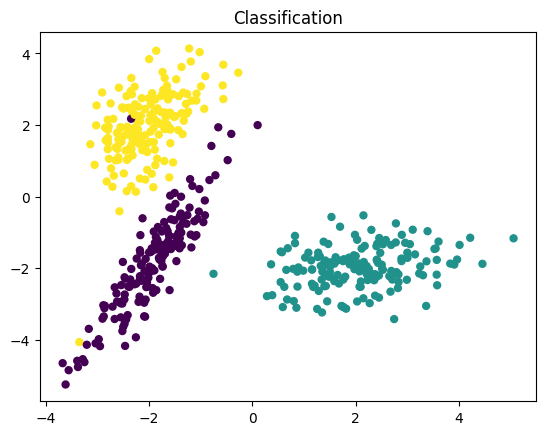

In [ ]:
plt.scatter(X_class[:, 0], X_class[:, 1], c=y_class, s=25)
plt.title("Classification")
plt.show()

In [ ]:
my_df = pd.read_csv('../data/Classification_smoke_detectors_filtered.csv', encoding="utf-8", index_col=0)

In [ ]:
X_real = my_df.drop(columns=['Fire Alarm'])
y_real = my_df['Fire Alarm']

In [ ]:
X_real.head()

## Рещение задачи кластеризации

In [ ]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, AffinityPropagation
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, calinski_harabasz_score, adjusted_rand_score, v_measure_score
import numpy as np

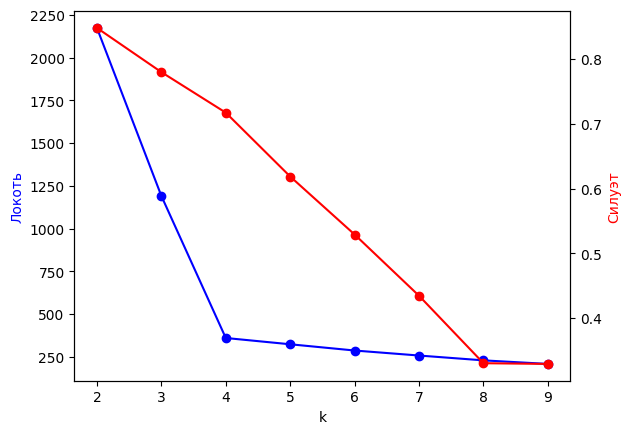

In [ ]:
def find_k(X):
    inertia = []
    sil = []
    k_range = range(2, 10)
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
        inertia.append(km.inertia_)
        sil.append(silhouette_score(X, km.labels_))
    
    fig, ax1 = plt.subplots()
    ax1.plot(k_range, inertia, 'bo-')
    ax1.set_xlabel('k')
    ax1.set_ylabel('Локоть', color='b')
    ax2 = ax1.twinx()
    ax2.plot(k_range, sil, 'ro-')
    ax2.set_ylabel('Силуэт', color='r')
    plt.show()

find_k(X_blobs) 

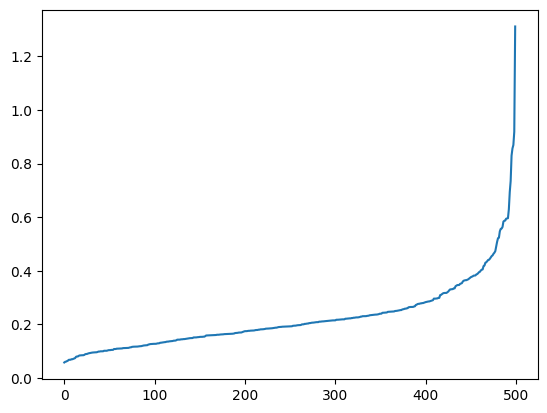

In [ ]:
def find_epsilon(X):
    neigh = NearestNeighbors(n_neighbors=4)
    nbrs = neigh.fit(X)
    distances, indices = nbrs.kneighbors(X)
    distances = np.sort(distances[:, 3], axis=0)
    plt.plot(distances)
    plt.show()

find_epsilon(X_blobs)


Анализ датасета: Blobs


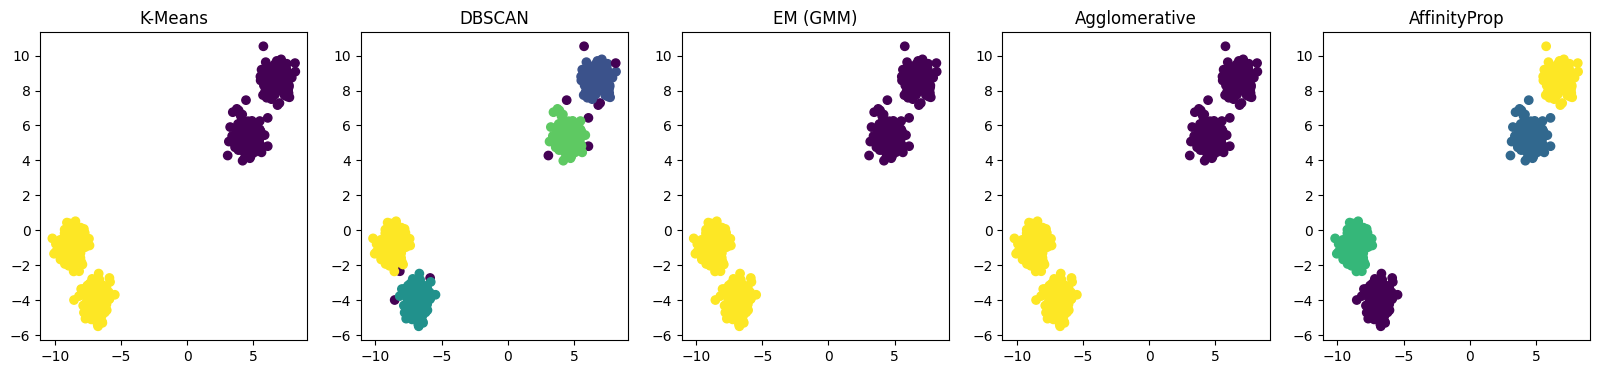

[DBSCAN]: Sil=0.69, Cal=4302.4 | ARI=0.97, V-m=0.95
[K-Means]: Sil=0.85, Cal=7720.2 | ARI=0.50, V-m=0.67
[EM-GMM]: Sil=0.85, Cal=7720.2 | ARI=0.50, V-m=0.67
[Agglomerative]: Sil=0.85, Cal=7720.2 | ARI=0.50, V-m=0.67
[AffinityProp]: Sil=0.72, Cal=16302.5 | ARI=1.00, V-m=1.00

Анализ датасета: Classification


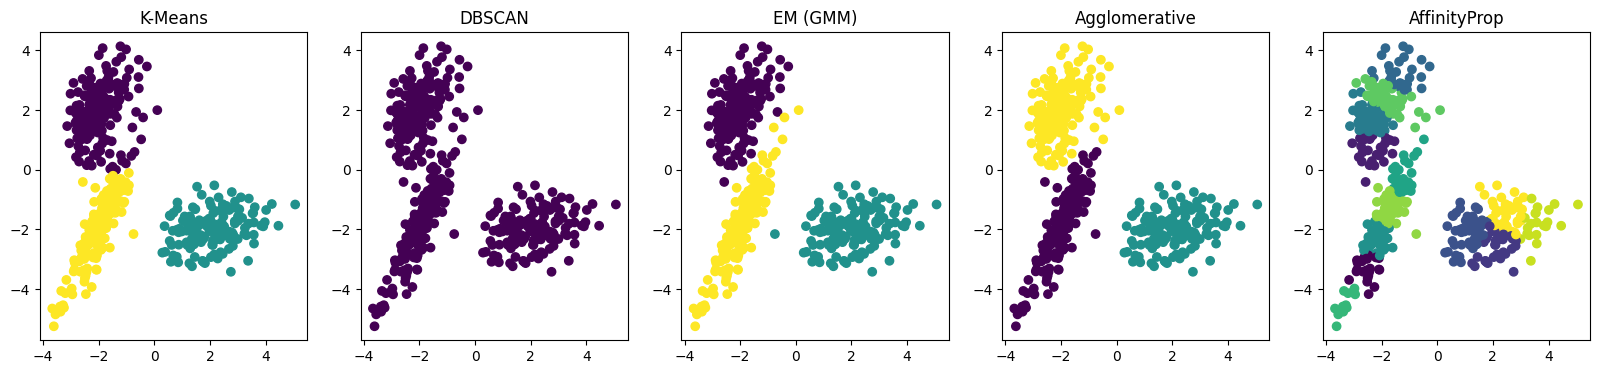

[DBSCAN]: Кластеризация не удалась (1 кластер или только шум)
[K-Means]: Sil=0.64, Cal=1360.0 | ARI=0.90, V-m=0.88
[EM-GMM]: Sil=0.62, Cal=1199.0 | ARI=0.98, V-m=0.97
[Agglomerative]: Sil=0.64, Cal=1318.0 | ARI=0.95, V-m=0.92
[AffinityProp]: Sil=0.36, Cal=1153.0 | ARI=0.31, V-m=0.58

Анализ датасета: Real Data
[DBSCAN]: Sil=0.57, Cal=90.9 | ARI=0.02, V-m=0.03
[K-Means]: Sil=0.45, Cal=520.8 | ARI=0.23, V-m=0.31
[EM-GMM]: Sil=0.44, Cal=489.3 | ARI=0.30, V-m=0.34
[Agglomerative]: Sil=0.40, Cal=502.5 | ARI=0.40, V-m=0.44
[AffinityProp]: Sil=0.39, Cal=503.1 | ARI=0.06, V-m=0.30


In [ ]:
datasets = [("Blobs", X_blobs, y_blobs), 
            ("Classification", X_class, y_class), 
            ("Real Data", X_real, y_real)]

for name, X_raw, y_true in datasets:
    if name == "Real Data":
        indices = np.random.choice(X_raw.shape[0], 1000, replace=False)
        X = X_raw.iloc[indices].values
        y_true = y_true[indices]
    else:
        X = X_raw
        
    print(f"\nАнализ датасета: {name}")
    
    k = 2 if name == "Blobs" else 3
    
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    
    current_eps = 0.3 if name == "Real Data" else (0.5 if name == "Blobs" else 1.5)
    db = DBSCAN(eps=current_eps, min_samples=5).fit(X)
    
    gm_labels = GaussianMixture(n_components=k, random_state=42).fit_predict(X)
    
    hc_labels = AgglomerativeClustering(n_clusters=k).fit_predict(X)
    
    ap = AffinityPropagation(damping=0.9, random_state=42).fit(X)
    ap_labels = ap.labels_

    results = {
        "DBSCAN": db.labels_,
        "K-Means": km.labels_,
        "EM-GMM": gm_labels,
        "Agglomerative": hc_labels,
        "AffinityProp": ap_labels
    }

    if name != "Real Data":
        fig, axes = plt.subplots(1, 5, figsize=(20, 4))
        axes[0].scatter(X[:,0], X[:,1], c=km.labels_, cmap='viridis'); axes[0].set_title('K-Means')
        axes[1].scatter(X[:,0], X[:,1], c=db.labels_, cmap='viridis'); axes[1].set_title('DBSCAN')
        axes[2].scatter(X[:,0], X[:,1], c=gm_labels, cmap='viridis'); axes[2].set_title('EM (GMM)')
        axes[3].scatter(X[:,0], X[:,1], c=hc_labels, cmap='viridis'); axes[3].set_title('Agglomerative')
        axes[4].scatter(X[:,0], X[:,1], c=ap_labels, cmap='viridis'); axes[4].set_title('AffinityProp')
        plt.show()

    for algo_name, labels in results.items():
        if len(set(labels)) > 1:
            sil = silhouette_score(X, labels)
            cal = calinski_harabasz_score(X, labels)
            ari = adjusted_rand_score(y_true, labels)
            vm = v_measure_score(y_true, labels)
            print(f"[{algo_name}]: Sil={sil:.2f}, Cal={cal:.1f} | ARI={ari:.2f}, V-m={vm:.2f}")
        else:
            print(f"[{algo_name}]: Кластеризация не удалась (1 кластер или только шум)")

## Кастомный K-Means

In [ ]:
from k_means_custom import KMeansCustom


Анализ датасета: Blobs


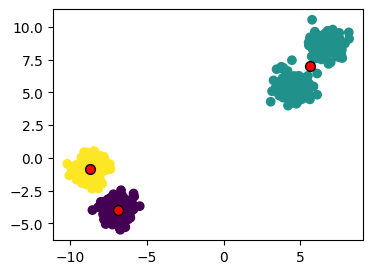

Sil=0.78, Cal=6389.7 | ARI=0.71, V-m=0.86

Анализ датасета: Classification


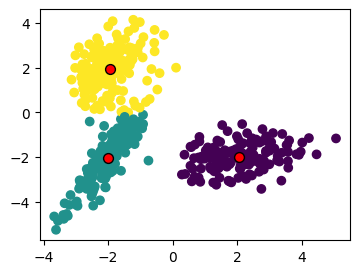

Sil=0.64, Cal=1360.0 | ARI=0.90, V-m=0.88

Анализ датасета: Real Data
Sil=0.45, Cal=567.0 | ARI=0.22, V-m=0.30


In [ ]:
for name, X_raw, y_true in datasets:
    if name == "Real Data":
        indices = np.random.choice(X_raw.shape[0], 1000, replace=False)
        X = X_raw.iloc[indices].values
        y_true = y_true[indices]
    else:
        X = X_raw

    custom_km = KMeansCustom()
    custom_km.fit(X)

    print(f"\nАнализ датасета: {name}")

    if name != "Real Data":
        fig, ax = plt.subplots(figsize=(4, 3)) 
        ax.scatter(X[:,0], X[:,1], c=custom_km.labels_, cmap='viridis')
        ax.scatter(custom_km.centroids[:, 0], custom_km.centroids[:, 1], c='red', marker='.', s=200, edgecolors='black')

        plt.show()
    
    sil = silhouette_score(X, custom_km.labels_)
    cal = calinski_harabasz_score(X, custom_km.labels_)
    ari = adjusted_rand_score(y_true, custom_km.labels_)
    vm = v_measure_score(y_true, custom_km.labels_)
    print(f"Sil={sil:.2f}, Cal={cal:.1f} | ARI={ari:.2f}, V-m={vm:.2f}")

## Вывод

На синтетических данных модели справились неплохо:
- Для датасета blobs показали себя хорошо DBSCAN и Affinity Propagation,
- С датасетом classification справились K-Means, EM и иерархическая кластеризация.

На реальных данных все модели показали низкие метрики.

Самостоятельно реализованный K-Means хорошо показал себя на датасете classification, чуть хуже на датасете blobs. На реальных данных метрики +- такие же низкие.